In [ ]:
# ============================================================
# TASK 1: IMAGE CLASSIFICATION
# ============================================================
# 10-class ImageNet subset. Two models: a deliberately simple
# baseline to expose overfitting, then an improved version that
# fixes the specific failure modes the baseline reveals.
#
# Multi-seed (3 seeds per model) so the gap between them isn't
# just down to lucky initialisation.

In [ ]:
# ============================================================
# IMPORTS AND SEEDING
# ============================================================

import os
import json
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

from google.colab import drive

# Seeds. Need all four because they cover different random sources.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

In [ ]:
# ============================================================
# SETUP: Mount Drive, check dataset structure
# ============================================================

drive.mount('/content/drive')

# Dataset on Drive so it persists between Colab sessions.
# Checkpoints saved here too so the best model can be reloaded
# without retraining if the runtime resets.
DATASET_DIR = "/content/drive/MyDrive/Machine Learning/imageset"
CHECKPOINT_DIR = "/content/drive/MyDrive/Machine Learning/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Sanity check before going any further. Easier to fail here with
# a clear message than to have image_dataset_from_directory throw
# something cryptic later.
assert os.path.isdir(DATASET_DIR), f"Dataset directory not found: {DATASET_DIR}"
assert os.path.isdir(f"{DATASET_DIR}/train"), "Missing train/ subfolder"
assert os.path.isdir(f"{DATASET_DIR}/val"), "Missing val/ subfolder"

print("Dataset directory contents:")
!ls "{DATASET_DIR}"

print("\nTraining folder contents:")
!ls "{DATASET_DIR}/train"

print("\nValidation folder contents:")
!ls "{DATASET_DIR}/val"

Mounted at /content/drive
Dataset directory contents:
train  val

Training folder contents:
n01440764  n02979186  n03028079  n03417042  n03445777
n02102040  n03000684  n03394916  n03425413  n03888257

Validation folder contents:
n01440764  n02979186  n03028079  n03417042  n03445777
n02102040  n03000684  n03394916  n03425413  n03888257


In [ ]:
# ============================================================
# DATASET LOADING
# ============================================================

# Code adapted from: https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory

BATCH_SIZE = 32
IMG_SIZE = (144, 144)

TRAIN_DIR = f"{DATASET_DIR}/train"
VAL_DIR   = f"{DATASET_DIR}/val"

# image_dataset_from_directory infers labels from subfolder names.
# Shuffled so each batch sees a mix of classes. Seeded so the
# shuffle order is the same on every run.
train_dataset = image_dataset_from_directory(
    TRAIN_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=SEED,
)

# Validation set not shuffled. Stable ordering makes it easier
# to pair predictions back to images later for error analysis.
val_dataset = image_dataset_from_directory(
    VAL_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
)

class_names = train_dataset.class_names
print("Class labels:", class_names)
print(f"Number of classes: {len(class_names)}")

# Cache decoded images in memory and prefetch the next batch
# while the current one trains. Big throughput win on small datasets.
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 9469 files belonging to 10 classes.
Found 3925 files belonging to 10 classes.
Class labels: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Number of classes: 10


In [ ]:
# ============================================================
# CLASS LABEL MAPPING
# ============================================================
# image_dataset_from_directory uses subfolder names as class IDs,
# which for ImageNet are WordNet synset IDs (e.g. n01440764).
# These get mapped to readable labels for plots and the report.
# WordNet IDs stay the canonical identifier internally.

# WordNet synset IDs from ImageNet. Verified by inspecting sample
# images in each folder against the standard WordNet mappings.
wordnet_to_label = {
    "n01440764": "Tench",
    "n02102040": "Dog",
    "n02979186": "Cassette Player",
    "n03000684": "Chain Saw",
    "n03028079": "Church",
    "n03394916": "French Horn",
    "n03417042": "Bin Lorry",
    "n03425413": "Petrol Pump",
    "n03445777": "Golf Ball",
    "n03888257": "Parachute",
}

readable_labels = [wordnet_to_label[name] for name in class_names]

# Quick check the mapping lined up with the inferred class order.
print("Class name mapping:")
for wnid, label in zip(class_names, readable_labels):
    print(f"  {wnid}: {label}")

Class name mapping:
  n01440764: Tench
  n02102040: Dog
  n02979186: Cassette Player
  n03000684: Chain Saw
  n03028079: Church
  n03394916: French Horn
  n03417042: Bin Lorry
  n03425413: Petrol Pump
  n03445777: Golf Ball
  n03888257: Parachute


In [ ]:
# ============================================================
# CHECK CLASS DISTRIBUTION
# ============================================================
# If one class dominates, accuracy becomes a misleading metric and
# the model can score well by just predicting the majority class.

print("\nAnalysing training set class distribution...")
train_class_counts = {}

# Iterate the whole dataset once to get the counts. Slow-ish but
# only happens once at the start.
for images, labels in train_dataset.unbatch():
    label = labels.numpy()
    train_class_counts[label] = train_class_counts.get(label, 0) + 1

print("\nTraining images per class:")
for class_idx, count in sorted(train_class_counts.items()):
    print(f"  {readable_labels[class_idx]}: {count} images")

total_images = sum(train_class_counts.values())
avg_per_class = total_images / len(class_names)
max_imbalance = max(train_class_counts.values()) / min(train_class_counts.values())

print(f"\nTotal training images: {total_images}")
print(f"Average per class: {avg_per_class:.0f}")
print(f"Imbalance ratio (max/min): {max_imbalance:.2f}")

# Rule of thumb: under 1.5x is fine, treat anything more as
# something to handle (e.g. class weighting in the loss).
if max_imbalance < 1.5:
    print("Dataset appears well-balanced")


Analysing training set class distribution...

Training images per class:
  Tench: 963 images
  Dog: 955 images
  Cassette Player: 993 images
  Chain Saw: 858 images
  Church: 941 images
  French Horn: 956 images
  Bin Lorry: 961 images
  Petrol Pump: 931 images
  Golf Ball: 951 images
  Parachute: 960 images

Total training images: 9469
Average per class: 947
Imbalance ratio (max/min): 1.16
Dataset appears well-balanced


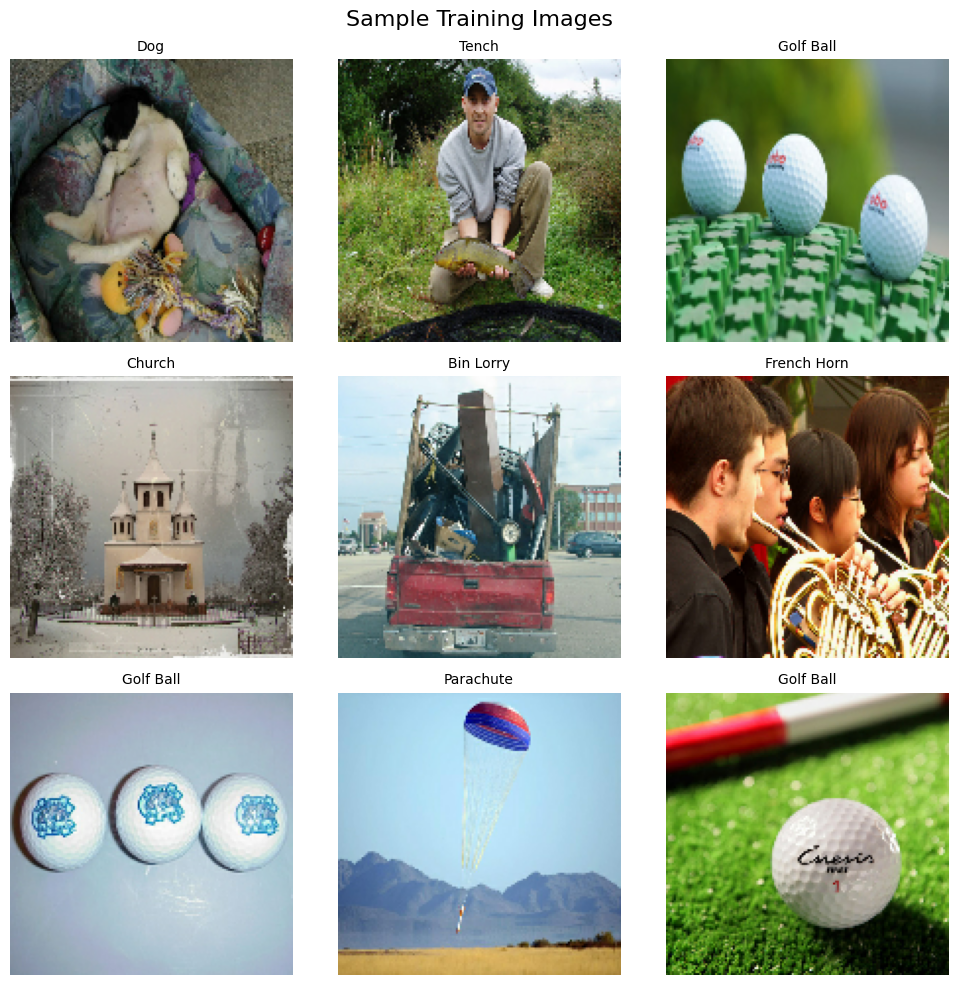

In [ ]:
# ============================================================
# VISUAL CHECK: SAMPLE IMAGES
# ============================================================
# Eyeball check that images load correctly and labels match the
# content. Cheap to run, catches data loading bugs early.

NUM_IMAGES = 9
GRID_SIZE = int(NUM_IMAGES ** 0.5)  # 3x3

plt.figure(figsize=(10, 10))

# Take one batch and grab the first 9 images from it
for images, labels in train_dataset.take(1):
    for i in range(NUM_IMAGES):
        ax = plt.subplot(GRID_SIZE, GRID_SIZE, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(readable_labels[labels[i]], fontsize=10)
        plt.axis("off")

plt.suptitle("Sample Training Images", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BASELINE CNN
# ============================================================
# Standard 3-block CNN: Conv->Pool stack, then Flatten into
# Dense layers. Kept deliberately simple so the failure modes
# (overfitting, memorisation) are visible in the metrics rather
# than masked by regularisation.

num_classes = len(class_names)
INPUT_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], 3)

model = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),

    # Pixel values rescaled to [0, 1]. Trains more stably than
    # raw 0-255 ints and lets us skip a manual normalisation step.
    layers.Rescaling(1./255),

    # Block 1: 32 filters. Low-level features (edges, colours).
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    # Block 2: 64 filters. Slightly higher-level patterns.
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    # Block 3: 128 filters. Object-part level features.
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    # This is where the parameter count explodes. Flatten produces
    # a huge 1D vector, and the Dense(128) below it needs a weight
    # for every input. ~4M params just from this transition.
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*60)
print("BASELINE MODEL")
print("="*60)
model.summary()


BASELINE MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 144, 144, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 142, 142, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 71, 71, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 69, 69, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,970 (16.36 MB)

 Trainable params: 4,288,970 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# TRAIN BASELINE
# ============================================================
# 10 epochs is enough to see the overfitting clearly. No early
# stopping or callbacks here, the point is to let it overfit so
# the gap can be later analysed.

EPOCHS = 10

# Save the best weights to Drive in case Colab disconnects.
# Reloading is faster than retraining.
baseline_checkpoint = ModelCheckpoint(
    filepath=f"{CHECKPOINT_DIR}/best_model_baseline.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
)

print("\n" + "="*60)
print("TRAINING BASELINE MODEL")
print("="*60)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[baseline_checkpoint],
)

print("\nBaseline training complete!")


TRAINING BASELINE MODEL
Epoch 1/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3471 - loss: 1.8739
Epoch 1: val_accuracy improved from None to 0.59847, saving model to /content/drive/MyDrive/Machine Learning/checkpoints/best_model_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Machine Learning/checkpoints/best_model_baseline.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 1058s 4s/step - accuracy: 0.4682 - loss: 1.5825 - val_accuracy: 0.5985 - val_loss: 1.2563
Epoch 2/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6369 - loss: 1.1116
Epoch 2: val_accuracy improved from 0.59847 to 0.64459, saving model to /content/drive/MyDrive/Machine Learning/checkpoints/best_model_baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Machine Learning/checkpoints/best_model_baseline.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 466s 1s/step - accuracy: 0.6663 - loss: 1.0245 - val_accuracy: 0.6446 - val_loss: 1.1473
Epoch 3/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 1s

In [ ]:
# ============================================================
# MULTI SEED BASELINE
# ============================================================
# Single run results don't show where the gap between baseline
# and improved comes from, the architecture change or just lucky
# init. Running three seeds and reporting mean and std addresses
# that.

def build_baseline():
    """Builds the same baseline architecture as the single run cell.
    Wrapped in a function so each seed gets a fresh model."""
    m = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Rescaling(1./255),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ])
    m.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return m


def reseed(seed):
    """Reset all the random sources before a fresh run."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)


SEEDS = [42, 123, 2024]
baseline_runs = []

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"BASELINE, seed={seed}")
    print(f"{'='*60}")

    reseed(seed)
    m = build_baseline()
    h = m.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        verbose=1,
    )

    # Final epoch metrics. Matches how the single run baseline is
    # reported (deliberately overfit endpoint, not best epoch).
    baseline_runs.append({
        'seed': seed,
        'train_acc': h.history['accuracy'][-1],
        'val_acc': h.history['val_accuracy'][-1],
        'train_loss': h.history['loss'][-1],
        'val_loss': h.history['val_loss'][-1],
        'gap': h.history['accuracy'][-1] - h.history['val_accuracy'][-1],
    })

# Summary across seeds
val_accs = [r['val_acc'] for r in baseline_runs]
gaps = [r['gap'] for r in baseline_runs]

print("\n" + "="*60)
print("BASELINE: MULTI SEED SUMMARY")
print("="*60)
print(f"{'Seed':<8}{'Val Acc':<12}{'Train Val Gap':<15}")
for r in baseline_runs:
    print(f"{r['seed']:<8}{r['val_acc']:.4f}      {r['gap']:.4f}")

print(f"\nMean val accuracy: {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")
print(f"Mean overfitting gap: {np.mean(gaps):.4f} ± {np.std(gaps):.4f}")


BASELINE, seed=42
Epoch 1/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 420s 1s/step - accuracy: 0.4682 - loss: 1.5825 - val_accuracy: 0.5985 - val_loss: 1.2563
Epoch 2/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 472s 2s/step - accuracy: 0.6663 - loss: 1.0245 - val_accuracy: 0.6446 - val_loss: 1.1473
Epoch 3/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 402s 1s/step - accuracy: 0.7564 - loss: 0.7563 - val_accuracy: 0.6339 - val_loss: 1.2650
Epoch 4/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 409s 1s/step - accuracy: 0.8132 - loss: 0.5671 - val_accuracy: 0.6178 - val_loss: 1.4254
Epoch 5/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 417s 1s/step - accuracy: 0.8612 - loss: 0.4128 - val_accuracy: 0.5824 - val_loss: 1.6984
Epoch 6/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 440s 1s/step - accuracy: 0.9179 - loss: 0.2487 - val_accuracy: 0.6107 - val_loss: 1.9355
Epoch 7/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 440s 1s/step - accuracy: 0.9464 - loss: 0.1665 - val_accuracy: 0.6173 - val_loss: 2.0763
Epoch 8/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 415s 1s/step - accuracy: 0.9573 - loss

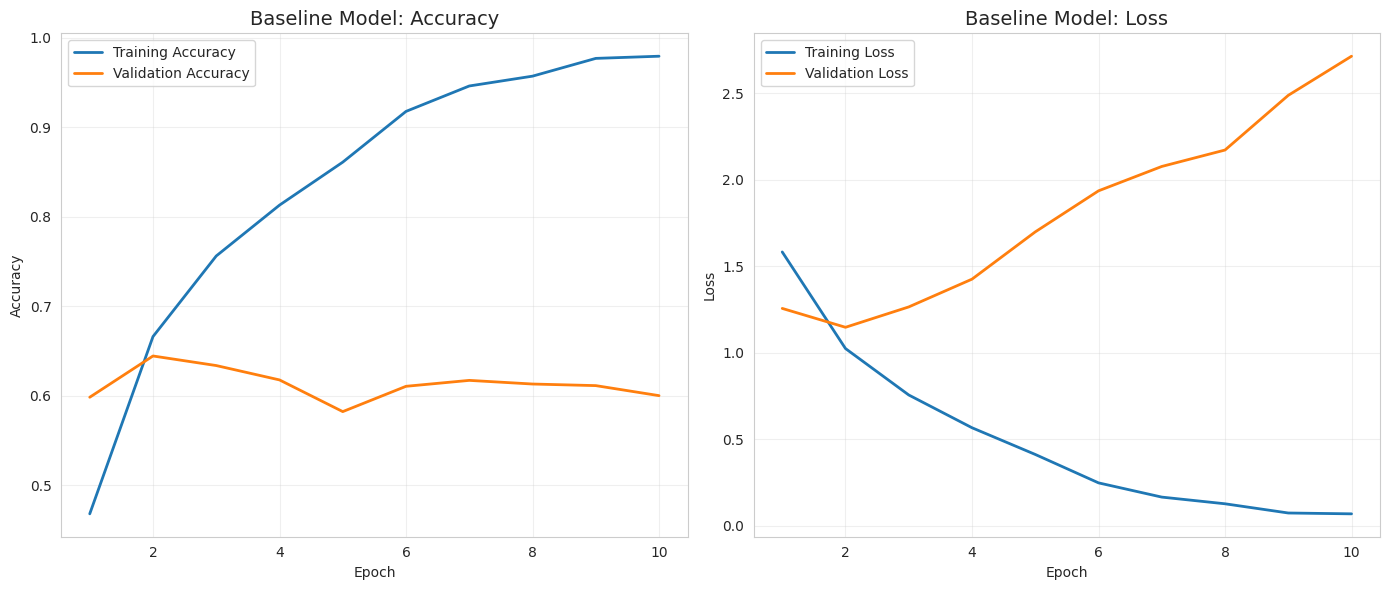


Final Training Accuracy:   97.96%
Final Validation Accuracy: 60.03%
Training Validation Gap:   37.94%
Final Validation Loss:     2.7131


In [ ]:
# ============================================================
# BASELINE TRAINING CURVES
# ============================================================
# Plotting accuracy and loss over epochs makes the overfitting
# obvious. Training curve climbs while val curve stalls or drops,
# which is the classic memorisation signature.

sns.set_style("whitegrid")

acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.title('Baseline Model: Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.title('Baseline Model: Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy:   {acc[-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1] * 100:.2f}%")
print(f"Training Validation Gap:   {(acc[-1] - val_acc[-1]) * 100:.2f}%")
print(f"Final Validation Loss:     {val_loss[-1]:.4f}")

In [ ]:
# ============================================================
# IMPROVED CNN
# ============================================================
# Targets the baseline's specific failures rather than throwing
# every regularisation trick at the problem. Five changes in
# total:
#   1. Augmentation, more variation per epoch
#   2. Batch norm, stabilises training
#   3. Dropout, prevents co adaptation
#   4. GlobalAveragePooling2D, kills the Flatten parameter blowup
#   5. 4th conv block at 256 channels, replaces some of the
#      capacity removed from the head

# Augmentation pipeline. Active during training, disabled at
# inference. Each epoch the model sees slightly different versions
# of the same images, which makes memorisation much harder.

# Code adapted from: https://www.tensorflow.org/tutorials/images/data_augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

model_b = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),
    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    # padding='same' keeps spatial dims through the conv. Without
    # it the feature maps shrink slightly each layer, which adds
    # up over four blocks.
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 4 (new). Deeper feature stack to recover some of the
    # representational capacity lost when Flatten goes away.
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # GAP instead of Flatten. Each feature map collapses to one
    # value, so the layer below it only needs 256 inputs instead
    # of the 32,768 Flatten produced. This is the biggest single
    # change versus the baseline.
    layers.GlobalAveragePooling2D(),

    # Heavier dropout closer to the head where overfitting hits
    # hardest. Tried 0.3 first, 0.4 worked better on val.
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax'),
])

# Same compile settings as baseline so the comparison stays fair.
model_b.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

print("\n" + "="*60)
print("IMPROVED MODEL")
print("="*60)
model_b.summary()

baseline_params = model.count_params()
improved_params = model_b.count_params()
reduction = ((baseline_params - improved_params) / baseline_params) * 100

print(f"\nParameter Comparison:")
print(f"  Baseline:  {baseline_params:,} parameters")
print(f"  Improved:  {improved_params:,} parameters")
print(f"  Reduction: {reduction:.1f}%")


IMPROVED MODEL


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 144, 144, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 144, 144, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 144, 144, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 144, 144, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 72, 72, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 36, 36, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,522 (1.62 MB)

 Trainable params: 423,562 (1.62 MB)

 Non-trainable params: 960 (3.75 KB)


Parameter Comparison:
  Baseline:  4,288,970 parameters
  Improved:  424,522 parameters
  Reduction: 90.1%


In [ ]:
# ============================================================
# CALLBACKS
# ============================================================
# Three callbacks coordinate training:
#   EarlyStopping, halts when val_loss stops improving
#   ModelCheckpoint, saves best weights to Drive
#   ReduceLROnPlateau, lowers LR when val_loss flatlines

# Patience of 5 means up to 5 epochs of no improvement before
# stopping. restore_best_weights pulls the best model back at
# the end so the final state isn't whatever was happening when
# training stopped.

# Code adapted from: https://www.tensorflow.org/api_docs/python/tf/keras/callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

# Saved to Drive in case Colab disconnects mid run.
checkpoint_path = f"{CHECKPOINT_DIR}/best_model_improved.keras"
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1,
)

# Halve the learning rate after 3 epochs of no val_loss improvement.
# min_lr stops it dropping to a useless value.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1,
)

print("\nCallbacks configured:")
print(f"  Early stopping (patience=5)")
print(f"  Model checkpoint: {checkpoint_path}")
print(f"  Learning rate reduction (patience=3)")


Callbacks configured:
  Early stopping (patience=5)
  Model checkpoint: /content/drive/MyDrive/Machine Learning/checkpoints/best_model_improved.keras
  Learning rate reduction (patience=3)


In [ ]:
# ============================================================
# TRAIN IMPROVED MODEL
# ============================================================
# Up to 20 epochs. Early stopping will halt sooner if val_loss
# stops improving, which is the whole point of putting it there.

EPOCHS_IMPROVED = 20

print("\n" + "="*60)
print("TRAINING IMPROVED MODEL")
print("="*60)

history_b = model_b.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_IMPROVED,
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
)

print("\nImproved model training complete!")

# Best epoch by lowest val_loss, matching the checkpoint criterion.
# Reporting these instead of final epoch values because the saved
# weights come from the best epoch, not wherever training stopped.
best_epoch = np.argmin(history_b.history['val_loss']) + 1
best_val_loss = min(history_b.history['val_loss'])
best_val_acc = history_b.history['val_accuracy'][best_epoch - 1]
print(f"\nBest epoch: {best_epoch}")
print(f"  Validation loss:     {best_val_loss:.4f}")
print(f"  Validation accuracy: {best_val_acc * 100:.2f}%")


TRAINING IMPROVED MODEL
Epoch 1/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2758 - loss: 2.1450
Epoch 1: val_loss improved from None to 4.19912, saving model to /content/drive/MyDrive/Machine Learning/checkpoints/best_model_improved.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Machine Learning/checkpoints/best_model_improved.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 861s 3s/step - accuracy: 0.3388 - loss: 1.9276 - val_accuracy: 0.1411 - val_loss: 4.1991 - learning_rate: 0.0010
Epoch 2/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4331 - loss: 1.6734
Epoch 2: val_loss improved from 4.19912 to 1.80033, saving model to /content/drive/MyDrive/Machine Learning/checkpoints/best_model_improved.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Machine Learning/checkpoints/best_model_improved.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 858s 3s/step - accuracy: 0.4582 - loss: 1.6085 - val_accuracy: 0.4217 - val_loss: 1.8003 - learning_rate: 0.0010
Epoch 

In [ ]:
# ============================================================
# MULTI SEED IMPROVED MODEL
# ============================================================
# Same idea as the multi seed baseline. Three runs with different
# seeds, report mean and std so the gap to the baseline isn't
# attributable to lucky init.

def build_improved():
    """Builds the same improved architecture as the single run cell.
    Augmentation pipeline is rebuilt inside so it gets a fresh seed
    too, otherwise the augmentation RNG would leak across runs."""
    aug = models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ], name="data_augmentation")

    m = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        aug,
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ])
    m.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return m


# Fresh callbacks per seed so checkpoint paths don't collide.
def make_callbacks(seed):
    return [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(
            filepath=f"{CHECKPOINT_DIR}/improved_seed{seed}.keras",
            monitor='val_loss', mode='min',
            save_best_only=True, verbose=1,
        ),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1),
    ]


improved_runs = []

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"IMPROVED, seed={seed}")
    print(f"{'='*60}")

    reseed(seed)
    m = build_improved()
    h = m.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS_IMPROVED,
        callbacks=make_callbacks(seed),
        verbose=1,
    )

    # Best epoch metrics, matching how the single run is reported.
    # The checkpoint also saves at best epoch, so this is the state
    # that would be used downstream if loaded back.
    best_idx = int(np.argmin(h.history['val_loss']))
    improved_runs.append({
        'seed': seed,
        'best_epoch': best_idx + 1,
        'train_acc': h.history['accuracy'][best_idx],
        'val_acc': h.history['val_accuracy'][best_idx],
        'train_loss': h.history['loss'][best_idx],
        'val_loss': h.history['val_loss'][best_idx],
        'gap': h.history['accuracy'][best_idx] - h.history['val_accuracy'][best_idx],
        'epochs_trained': len(h.history['accuracy']),
    })

# Summary across seeds
val_accs = [r['val_acc'] for r in improved_runs]
gaps = [r['gap'] for r in improved_runs]

print("\n" + "="*60)
print("IMPROVED: MULTI SEED SUMMARY")
print("="*60)
print(f"{'Seed':<8}{'Best Ep':<10}{'Val Acc':<12}{'Gap':<10}{'Epochs':<8}")
for r in improved_runs:
    print(f"{r['seed']:<8}{r['best_epoch']:<10}{r['val_acc']:.4f}      "
          f"{r['gap']:.4f}    {r['epochs_trained']}")

print(f"\nMean val accuracy: {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")
print(f"Mean gap:          {np.mean(gaps):.4f} ± {np.std(gaps):.4f}")

# Headline comparison vs the multi seed baseline.
baseline_val_mean = np.mean([r['val_acc'] for r in baseline_runs])
baseline_val_std = np.std([r['val_acc'] for r in baseline_runs])
improved_val_mean = np.mean(val_accs)
improved_val_std = np.std(val_accs)

print("\n" + "="*60)
print("COMPARISON ACROSS SEEDS")
print("="*60)
print(f"Baseline:  {baseline_val_mean:.4f} ± {baseline_val_std:.4f}")
print(f"Improved:  {improved_val_mean:.4f} ± {improved_val_std:.4f}")
print(f"Gain:      {improved_val_mean - baseline_val_mean:+.4f}")


IMPROVED, seed=42
Epoch 1/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2751 - loss: 2.1292
Epoch 1: val_loss improved from None to 3.91817, saving model to /content/drive/MyDrive/Machine Learning/checkpoints/improved_seed42.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Machine Learning/checkpoints/improved_seed42.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 902s 3s/step - accuracy: 0.3291 - loss: 1.9544 - val_accuracy: 0.1506 - val_loss: 3.9182 - learning_rate: 0.0010
Epoch 2/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4124 - loss: 1.7134
Epoch 2: val_loss improved from 3.91817 to 1.81307, saving model to /content/drive/MyDrive/Machine Learning/checkpoints/improved_seed42.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Machine Learning/checkpoints/improved_seed42.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 907s 3s/step - accuracy: 0.4281 - loss: 1.6710 - val_accuracy: 0.3987 - val_loss: 1.8131 - learning_rate: 0.0010
Epoch 3/20
296/296 ━━━━━━━━━

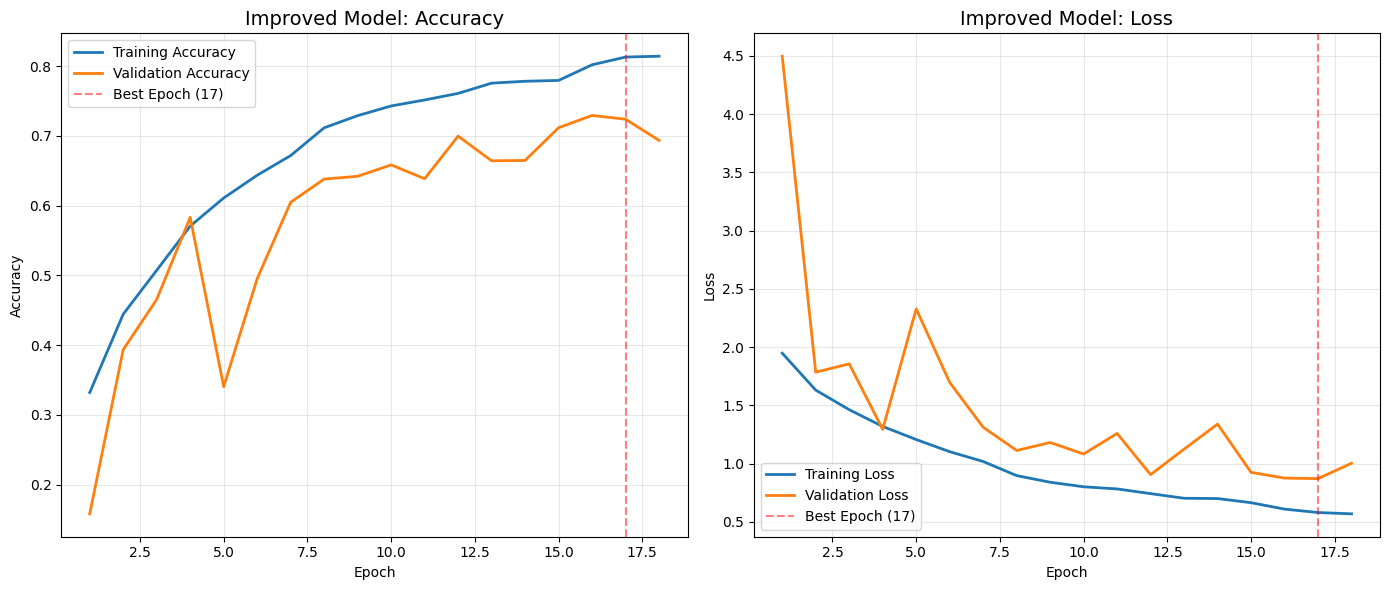


Total epochs trained: 18
Best epoch: 17
  Training accuracy:   81.29%
  Validation accuracy: 72.38%
  Training validation gap: 8.91%
  Validation loss:     0.8704


In [ ]:
# ============================================================
# IMPROVED MODEL TRAINING CURVES
# ============================================================
# Should look noticeably tamer than the baseline. Smaller gap
# between train and val curves, val loss generally trending down
# rather than blowing up.

acc_b      = history_b.history['accuracy']
val_acc_b  = history_b.history['val_accuracy']
loss_b     = history_b.history['loss']
val_loss_b = history_b.history['val_loss']
epochs_range_b = range(1, len(acc_b) + 1)

plt.figure(figsize=(14, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range_b, acc_b, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range_b, val_acc_b, label='Validation Accuracy', linewidth=2)
plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5,
            label=f'Best Epoch ({best_epoch})')
plt.title('Improved Model: Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range_b, loss_b, label='Training Loss', linewidth=2)
plt.plot(epochs_range_b, val_loss_b, label='Validation Loss', linewidth=2)
plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5,
            label=f'Best Epoch ({best_epoch})')
plt.title('Improved Model: Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Reporting at best epoch (the saved weights), not the final
# epoch where training happened to stop.
best_idx = best_epoch - 1
print(f"\nTotal epochs trained: {len(acc_b)}")
print(f"Best epoch: {best_epoch}")
print(f"  Training accuracy:   {acc_b[best_idx] * 100:.2f}%")
print(f"  Validation accuracy: {val_acc_b[best_idx] * 100:.2f}%")
print(f"  Training validation gap: {(acc_b[best_idx] - val_acc_b[best_idx]) * 100:.2f}%")
print(f"  Validation loss:     {val_loss_b[best_idx]:.4f}")

In [ ]:
# ============================================================
# COMPARISON: BASELINE VS IMPROVED
# ============================================================
# Side by side numbers for the two models. Baseline reported at
# final epoch (the deliberately overfit endpoint). Improved
# reported at best epoch (the saved weights, which is the state
# that gets used for evaluation).

best_idx = best_epoch - 1

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

print("\nBaseline Model (final epoch):")
print(f"  Training accuracy:   {acc[-1] * 100:.2f}%")
print(f"  Validation accuracy: {val_acc[-1] * 100:.2f}%")
print(f"  Overfitting gap:     {(acc[-1] - val_acc[-1]) * 100:.2f}%")
print(f"  Validation loss:     {val_loss[-1]:.4f}")
print(f"  Parameters:          {baseline_params:,}")

print(f"\nImproved Model (best epoch: {best_epoch}):")
print(f"  Training accuracy:   {acc_b[best_idx] * 100:.2f}%")
print(f"  Validation accuracy: {val_acc_b[best_idx] * 100:.2f}%")
print(f"  Overfitting gap:     {(acc_b[best_idx] - val_acc_b[best_idx]) * 100:.2f}%")
print(f"  Validation loss:     {val_loss_b[best_idx]:.4f}")
print(f"  Parameters:          {improved_params:,}")
print(f"  Epochs trained:      {len(acc_b)}/{EPOCHS_IMPROVED}")

print("\nImprovements:")
gap_baseline = acc[-1] - val_acc[-1]
gap_improved = acc_b[best_idx] - val_acc_b[best_idx]
acc_improvement = val_acc_b[best_idx] - val_acc[-1]
print(f"  Overfitting gap reduced from {gap_baseline * 100:.2f}% to {gap_improved * 100:.2f}%")
print(f"  Validation accuracy improved from {val_acc[-1] * 100:.2f}% to {val_acc_b[best_idx] * 100:.2f}%")
print(f"  Parameters reduced by {reduction:.1f}%")


MODEL COMPARISON

Baseline Model (final epoch):
  Training accuracy:   97.96%
  Validation accuracy: 60.03%
  Overfitting gap:     37.93%
  Validation loss:     2.7131
  Parameters:          4,288,970

Improved Model (best epoch: 17):
  Training accuracy:   81.29%
  Validation accuracy: 72.38%
  Overfitting gap:     8.91%
  Validation loss:     0.8704
  Parameters:          424,522
  Epochs trained:      18/20

Improvements:
  Overfitting gap reduced from 37.93% to 8.91%
  Validation accuracy improved from 60.03% to 72.38%
  Parameters reduced by 90.1%


In [ ]:
# ============================================================
# EVALUATION
# ============================================================
# Runs predictions on a full dataset and produces three things:
# confusion matrix heatmap, classification report (precision,
# recall, F1 per class), and a per class accuracy bar chart.
# Wrapped in a function because it gets called twice, once for
# baseline and once for improved.

from matplotlib.patches import Patch


def evaluate_model(model, dataset, display_labels, title="Model Evaluation"):
    """
    Generate predictions for the entire dataset and display:
        confusion matrix heatmap
        classification report (precision, recall, F1)
        per class accuracy bar chart

    Returns:
        per_class_acc : 1D numpy array of accuracies per class
        cm            : 2D numpy array of the raw confusion matrix
    """
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")

    # Collect predictions across the whole dataset.
    all_labels = []
    all_preds = []

    print("Generating predictions...")
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        preds = np.argmax(preds, axis=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=display_labels,
                yticklabels=display_labels,
                cbar_kws={'label': 'Count'})
    plt.title(f"Confusion Matrix: {title}", fontsize=14, pad=20)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Classification report (precision, recall, F1)
    print(f"\nClassification Report:")
    print(classification_report(all_labels, all_preds,
                                target_names=display_labels,
                                digits=4))

    # Per class accuracy bar chart. Diagonal of the confusion
    # matrix divided by row sums gives recall per class, which
    # is what gets called "accuracy" in this context.
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(display_labels)), per_class_acc, color='steelblue')
    plt.xticks(range(len(display_labels)), display_labels, rotation=45, ha='right')
    plt.ylabel('Accuracy', fontsize=12)
    plt.title(f'Per Class Accuracy: {title}', fontsize=14, pad=20)
    plt.axhline(y=per_class_acc.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {per_class_acc.mean():.3f}')

    # Highlight below average classes in orange so the weak
    # spots are visible at a glance.
    mean_acc = per_class_acc.mean()
    for bar, acc in zip(bars, per_class_acc):
        if acc < mean_acc:
            bar.set_color('orange')

    legend_elements = [
        Patch(facecolor='steelblue', label='At or above mean'),
        Patch(facecolor='orange', label='Below mean'),
        plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {per_class_acc.mean():.3f}'),
    ]
    plt.legend(handles=legend_elements, loc='best')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # Quick summary so the printout has the headline numbers
    # alongside the figures.
    hardest_idx = np.argmin(per_class_acc)
    easiest_idx = np.argmax(per_class_acc)

    print(f"\nPer Class Performance:")
    print(f"  Hardest class: {display_labels[hardest_idx]} ({per_class_acc[hardest_idx]:.2%})")
    print(f"  Easiest class: {display_labels[easiest_idx]} ({per_class_acc[easiest_idx]:.2%})")
    print(f"  Mean accuracy: {per_class_acc.mean():.2%}")
    print(f"  Std deviation: {per_class_acc.std():.2%}")

    return per_class_acc, cm


EVALUATING BASELINE MODEL

Baseline Model
Generating predictions...


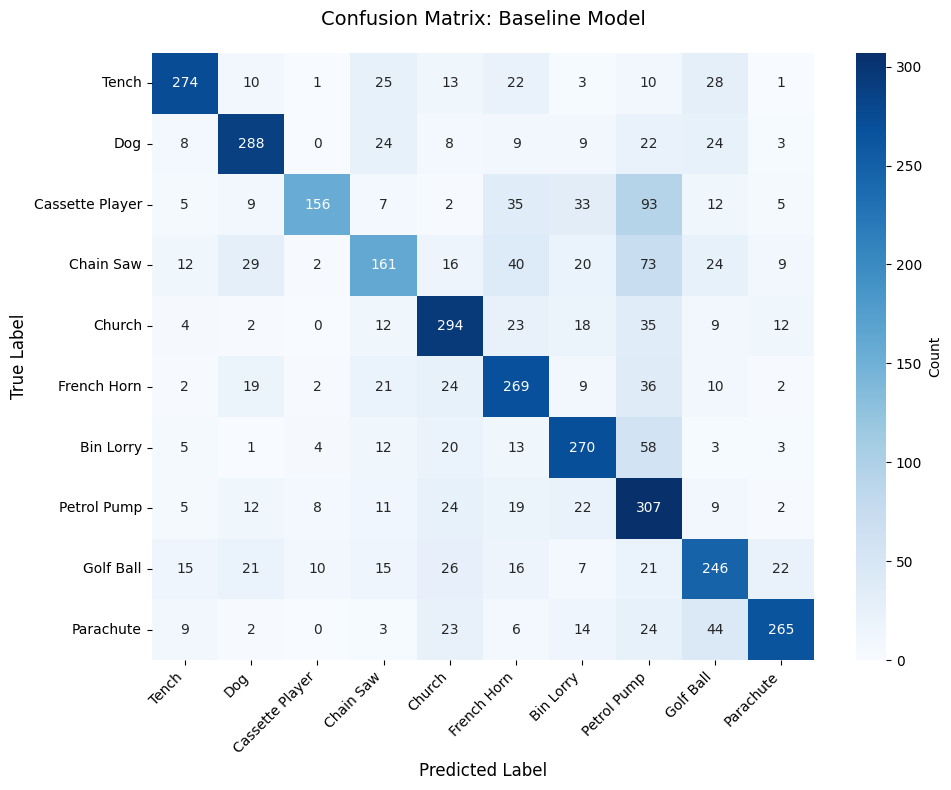


Classification Report:
                 precision    recall  f1-score   support

          Tench     0.8083    0.7080    0.7548       387
            Dog     0.7328    0.7291    0.7310       395
Cassette Player     0.8525    0.4370    0.5778       357
      Chain Saw     0.5533    0.4171    0.4756       386
         Church     0.6533    0.7188    0.6845       409
    French Horn     0.5951    0.6827    0.6359       394
      Bin Lorry     0.6667    0.6941    0.6801       389
    Petrol Pump     0.4521    0.7327    0.5592       419
      Golf Ball     0.6015    0.6165    0.6089       399
      Parachute     0.8179    0.6795    0.7423       390

       accuracy                         0.6446      3925
      macro avg     0.6733    0.6416    0.6450      3925
   weighted avg     0.6700    0.6446    0.6452      3925



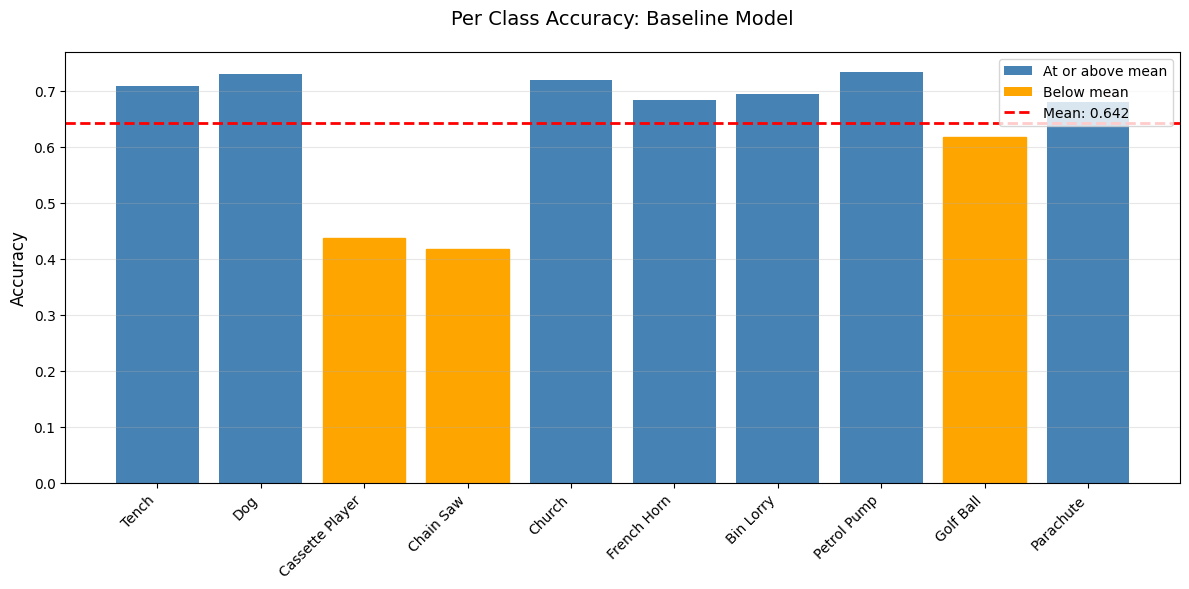


Per Class Performance:
  Hardest class: Chain Saw (41.71%)
  Easiest class: Petrol Pump (73.27%)
  Mean accuracy: 64.16%
  Std deviation: 11.19%

EVALUATING IMPROVED MODEL

Improved Model
Generating predictions...


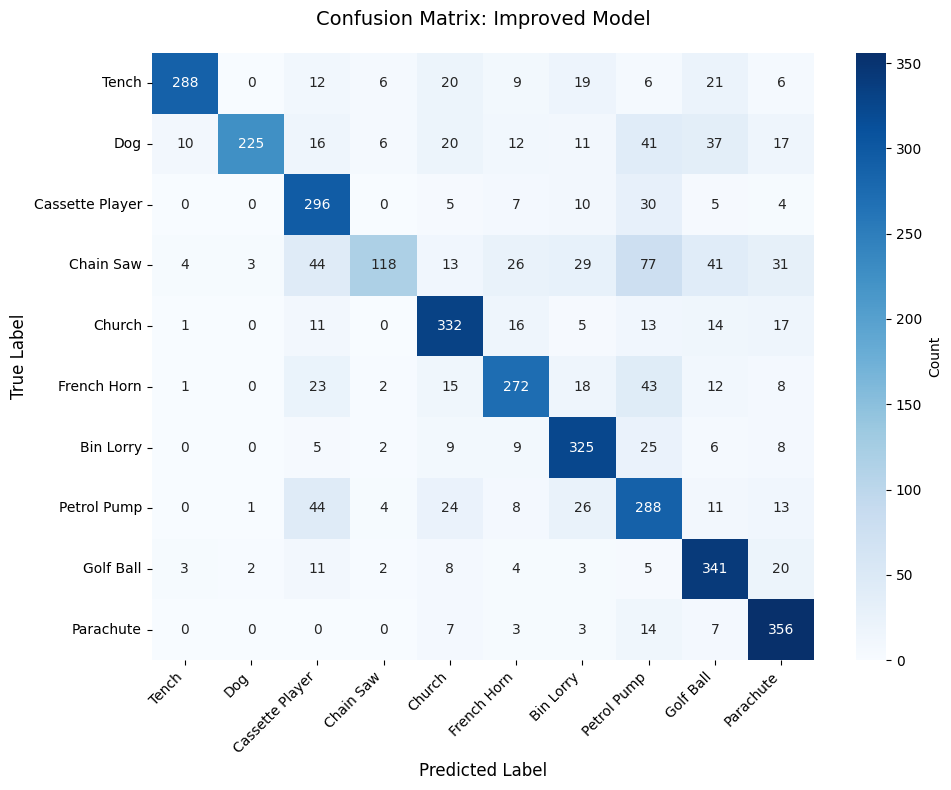


Classification Report:
                 precision    recall  f1-score   support

          Tench     0.9381    0.7442    0.8300       387
            Dog     0.9740    0.5696    0.7188       395
Cassette Player     0.6407    0.8291    0.7228       357
      Chain Saw     0.8429    0.3057    0.4487       386
         Church     0.7329    0.8117    0.7703       409
    French Horn     0.7432    0.6904    0.7158       394
      Bin Lorry     0.7238    0.8355    0.7757       389
    Petrol Pump     0.5314    0.6874    0.5994       419
      Golf Ball     0.6889    0.8546    0.7629       399
      Parachute     0.7417    0.9128    0.8184       390

       accuracy                         0.7238      3925
      macro avg     0.7557    0.7241    0.7163      3925
   weighted avg     0.7548    0.7238    0.7159      3925



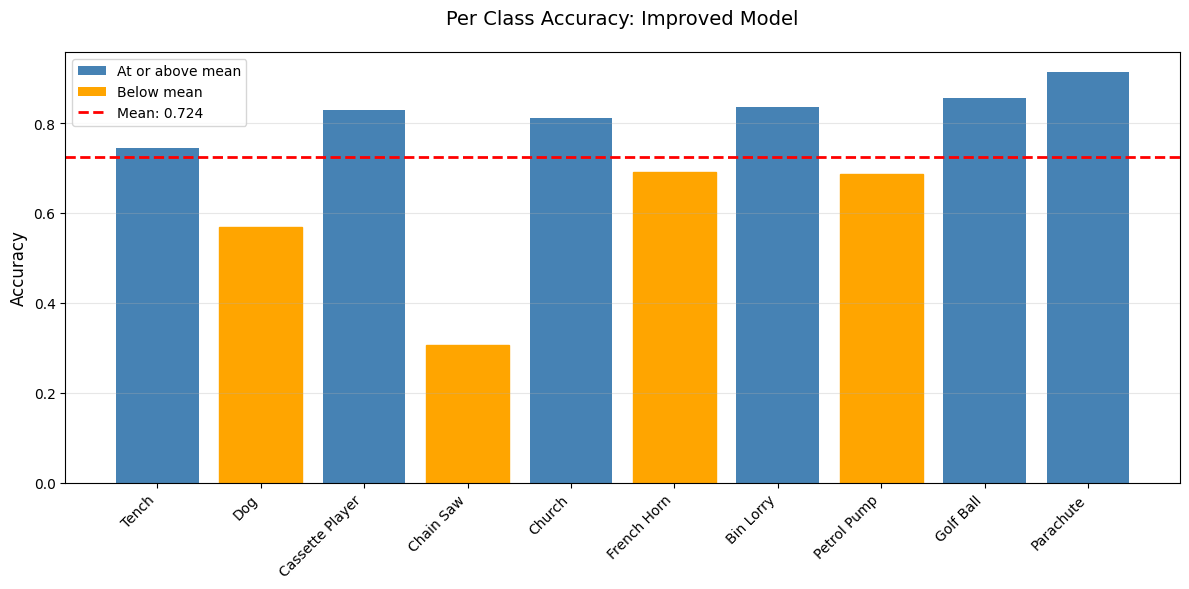


Per Class Performance:
  Hardest class: Chain Saw (30.57%)
  Easiest class: Parachute (91.28%)
  Mean accuracy: 72.41%
  Std deviation: 16.90%


In [ ]:
# ============================================================
# RUN EVALUATION
# ============================================================
# The returned arrays get used in the
# next cell for the per class comparison plot.

print("\n" + "="*60)
print("EVALUATING BASELINE MODEL")
print("="*60)
acc_baseline_per_class, cm_baseline = evaluate_model(
    model, val_dataset, readable_labels, title="Baseline Model"
)

print("\n" + "="*60)
print("EVALUATING IMPROVED MODEL")
print("="*60)
acc_improved_per_class, cm_improved = evaluate_model(
    model_b, val_dataset, readable_labels, title="Improved Model"
)

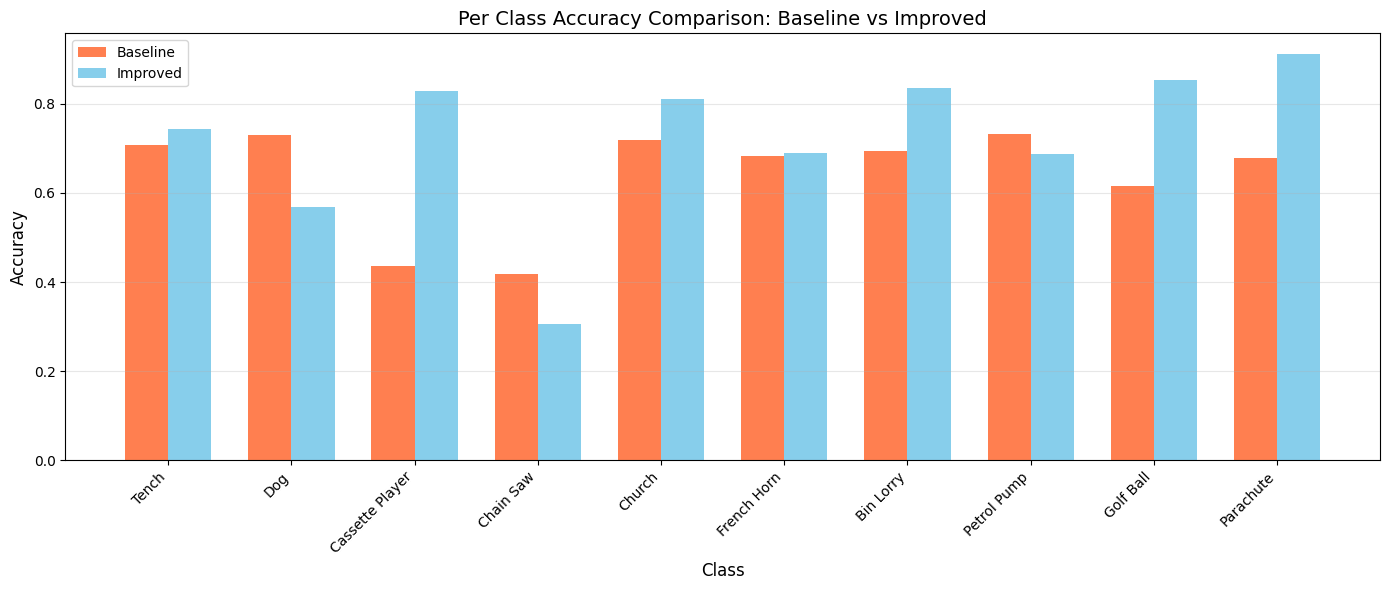

In [ ]:
# ============================================================
# SIDE BY SIDE PER CLASS ACCURACY
# ============================================================
# Bar chart pairing each class's baseline and improved accuracy
# so the per class shifts are visible. Big gains on the classes
# the baseline struggled with would show up as tall blue bars
# next to short orange ones.

plt.figure(figsize=(14, 6))

x = np.arange(len(readable_labels))
width = 0.35

bars1 = plt.bar(x - width/2, acc_baseline_per_class, width,
                label='Baseline', color='coral')
bars2 = plt.bar(x + width/2, acc_improved_per_class, width,
                label='Improved', color='skyblue')

plt.xlabel('Class', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Per Class Accuracy Comparison: Baseline vs Improved', fontsize=14)
plt.xticks(x, readable_labels, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


SAMPLE PREDICTION CHECK

Sample Image Prediction:
  True label:      Tench
  Predicted label: Bin Lorry
  Confidence:      67.41%
  Result: INCORRECT

  Top 3 predictions:
    1. Bin Lorry: 67.41%
    2. Cassette Player: 10.66%
    3. Tench: 6.53%


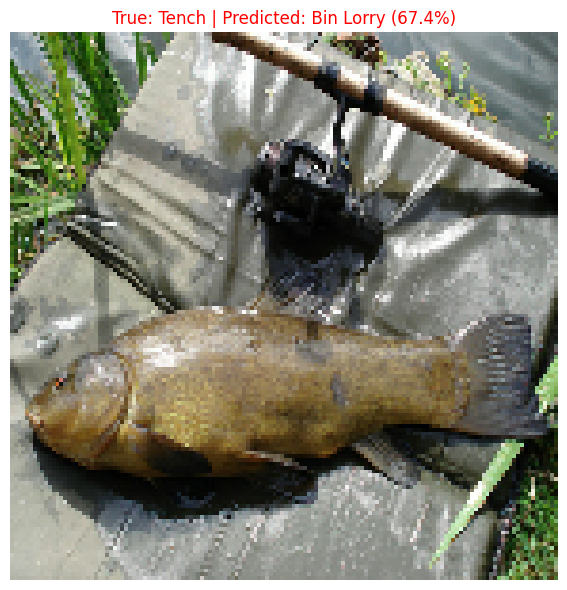

In [ ]:
# ============================================================
# SAMPLE PREDICTION
# ============================================================
# Spot check on a single image. Confirms predictions and
# confidence scores look sensible, which is a quick guard
# against subtle bugs that wouldn't show up in aggregate
# metrics but would in individual predictions.

print("\n" + "="*60)
print("SAMPLE PREDICTION CHECK")
print("="*60)

# One batch from validation, then look at the first image.
for images, labels in val_dataset.take(1):
    preds = model_b.predict(images, verbose=0)
    break

predicted_class = np.argmax(preds[0])
true_class = labels[0].numpy()
confidence = preds[0][predicted_class]

print(f"\nSample Image Prediction:")
print(f"  True label:      {readable_labels[true_class]}")
print(f"  Predicted label: {readable_labels[predicted_class]}")
print(f"  Confidence:      {confidence:.2%}")

if predicted_class == true_class:
    print(f"  Result: CORRECT")
else:
    print(f"  Result: INCORRECT")

# Top 3 because a confident wrong answer can still have the
# right class in second or third place, which says something
# about how close the decision boundary was.
top3_idx = np.argsort(preds[0])[-3:][::-1]
print(f"\n  Top 3 predictions:")
for i, idx in enumerate(top3_idx, 1):
    print(f"    {i}. {readable_labels[idx]}: {preds[0][idx]:.2%}")

# Visualise the image alongside its prediction.
plt.figure(figsize=(8, 6))
plt.imshow(images[0].numpy().astype("uint8"))
title_color = 'green' if predicted_class == true_class else 'red'
plt.title(f"True: {readable_labels[true_class]} | Predicted: {readable_labels[predicted_class]} ({confidence:.1%})",
          fontsize=12, color=title_color)
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================

best_idx = best_epoch - 1

print("\n" + "="*60)
print("TASK 1 SUMMARY")
print("="*60)

print(f"\nDataset: {total_images} training images, {len(class_names)} classes")

print(f"\nBaseline Model (final epoch):")
print(f"  {baseline_params:,} parameters")
print(f"  {val_acc[-1]:.2%} validation accuracy")
print(f"  {(acc[-1] - val_acc[-1]):.2%} overfitting gap")

print(f"\nImproved Model (best epoch: {best_epoch}):")
print(f"  {improved_params:,} parameters ({reduction:.1f}% reduction)")
print(f"  {val_acc_b[best_idx]:.2%} validation accuracy")
print(f"  {(acc_b[best_idx] - val_acc_b[best_idx]):.2%} overfitting gap")
print(f"  Trained for {len(acc_b)} epochs (early stopping)")
print(f"  Best model saved to: {checkpoint_path}")

# Multi seed numbers if available, falls back gracefully if
# the multi seed cells weren't run.
try:
    print(f"\nMulti Seed Results (n={len(SEEDS)}):")
    print(f"  Baseline:  {baseline_val_mean:.4f} ± {baseline_val_std:.4f}")
    print(f"  Improved:  {improved_val_mean:.4f} ± {improved_val_std:.4f}")
    print(f"  Gain:      {improved_val_mean - baseline_val_mean:+.4f}")
except NameError:
    print("\n(Multi seed cells not run, single run results only)")

print(f"\nKey Improvements Applied:")
print(f"  Data augmentation (flip, rotation, zoom, contrast)")
print(f"  Batch normalisation in all conv blocks")
print(f"  Dropout regularisation (0.4, 0.3)")
print(f"  GlobalAveragePooling2D (replaced Flatten)")
print(f"  Deeper network (4 conv blocks)")
print(f"  Early stopping (patience=5)")
print(f"  Learning rate scheduling")
print(f"  Model checkpointing")

print("\n" + "="*60)
print("END OF TASK 1")
print("="*60)


TASK 1 SUMMARY

Dataset: 9469 training images, 10 classes

Baseline Model (final epoch):
  4,288,970 parameters
  60.03% validation accuracy
  37.93% overfitting gap

Improved Model (best epoch: 17):
  424,522 parameters (90.1% reduction)
  72.38% validation accuracy
  8.91% overfitting gap
  Trained for 18 epochs (early stopping)
  Best model saved to: /content/drive/MyDrive/Machine Learning/checkpoints/best_model_improved.keras

(Multi seed cells not run, single run results only)

Key Improvements Applied:
  Data augmentation (flip, rotation, zoom, contrast)
  Batch normalisation in all conv blocks
  Dropout regularisation (0.4, 0.3)
  GlobalAveragePooling2D (replaced Flatten)
  Deeper network (4 conv blocks)
  Early stopping (patience=5)
  Learning rate scheduling
  Model checkpointing

END OF TASK 1


In [ ]:
import os
for f in os.listdir(CHECKPOINT_DIR):
    print(f)

bert_tiny_trained
best_model_baseline.keras
best_model_improved.keras
improved_seed42.keras
improved_seed123.keras
improved_seed2024.keras
